# PGD Adversarial Attack Against Intrusion Detection System

## Research Statement

The problem statement is to evaluate the vulnerability of a neural network-based intrusion detection system through the **Projected Gradient Descent (PGD)** adversarial attack. The hypothesis is that the PGD attack — being a stronger, iterative extension of FGSM — will be more effective at evading detection than single-step attacks, especially as the number of iterations and step sizes are optimized.

PGD is widely considered the **gold standard** for adversarial robustness evaluation. Unlike FGSM, which applies a single large perturbation step, PGD iteratively applies small perturbations and projects them back into a constrained ε-ball around the original input. This allows PGD to find **worst-case adversarial examples** within the perturbation budget, making it a more realistic and dangerous adversarial threat.

This notebook contains:
- Training and evaluation of a Feedforward Neural Network IDS victim model
- Implementation of the PGD attack with configurable ε, step size α, and iteration count K
- Comparative analysis across perturbation budgets and iteration depths
- ROC curve analysis showing degradation under iterative attack pressure

## Import Libraries

Make sure to install the following dependencies before running:
- **Pandas** — data manipulation
- **Numpy** — numerical computation
- **Torch** — neural network model and gradient computation
- **Sklearn** — preprocessing and evaluation metrics
- **Matplotlib** — visualization

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

## Load and Preprocess Training Dataset with Feature Engineering

The dataset is loaded from `cybersecurity_intrusion_data.csv`. Preprocessing includes:
- Dropping non-feature columns (`session_id`)
- One-hot encoding categorical features (`protocol_type`, `encryption_used`, `browser_type`)
- Standardizing numerical features
- Engineering derived features: `login_attempt_rate` and `failed_login_ratio`

The preprocessed data is split 80/20 into training and validation sets using `train_test_split`.

In [6]:
# Load the data
data = pd.read_csv('cybersecurity_intrusion_data.csv')

# Preprocess the data
X = data.drop(['attack_detected'], axis=1)
y = data['attack_detected']

# Drop the session_id column
X = X.drop('session_id', axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['protocol_type', 'encryption_used', 'browser_type'])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['network_packet_size', 'login_attempts', 'session_duration',
                  'ip_reputation_score', 'failed_logins', 'unusual_time_access']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Feature engineering
X['login_attempt_rate'] = X['login_attempts'] / X['session_duration']
X['failed_login_ratio'] = X['failed_logins'] / (X['login_attempts'] + 1)

# Scale new features
X[['login_attempt_rate', 'failed_login_ratio']] = scaler.fit_transform(
    X[['login_attempt_rate', 'failed_login_ratio']])

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure all columns are numerical
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_train = X_train.dropna()
y_train = y_train[X_train.index]

print(f'Training set size: {X_train.shape[0]}')
print(f'Validation set size: {X_val.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')

Training set size: 7629
Validation set size: 1908
Number of features: 18


## Define the Intrusion Detection Model

A simple 3-layer feedforward neural network with ReLU activations:
- **Layer 1:** `input_dim → 128`
- **Layer 2:** `128 → 64`
- **Layer 3:** `64 → 2` (binary classification: attack / no attack)

Trained using **CrossEntropyLoss** and **Adam optimizer**.

In [7]:
# Define the dataset class
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        X = X.copy()
        bool_cols = ['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
                     'encryption_used_AES', 'encryption_used_DES',
                     'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
                     'browser_type_Safari', 'browser_type_Unknown']
        X[bool_cols] = X[bool_cols].astype(float)
        self.X = torch.tensor(X.values, dtype=torch.float32)
        if isinstance(y, pd.Series):
            self.y = torch.tensor(y.values, dtype=torch.long)
        else:
            self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


# Define the model
class Net(nn.Module):
    def __init__(self, input_dim):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Initialize model
model = Net(input_dim=X_train.shape[1])
print(model)

Net(
  (fc1): Linear(in_features=18, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


## Train the Intrusion Detection Model

The model trains over 10 epochs using mini-batches of size 32. After each epoch, validation accuracy is reported to monitor learning progress.

In [8]:
# Train model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = Dataset(X_train, y_train)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

def convert_bool_to_float(X):
    bool_cols = ['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
                 'encryption_used_AES', 'encryption_used_DES',
                 'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
                 'browser_type_Safari', 'browser_type_Unknown']
    X[bool_cols] = X[bool_cols].astype(float)
    return X

for epoch in range(10):
    model.train()
    total_loss = 0
    for X_batch, y_batch in data_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {total_loss / len(data_loader):.4f}')

    X_val_float = convert_bool_to_float(X_val.copy())
    model.eval()
    with torch.no_grad():
        outputs = model(torch.tensor(X_val_float.values, dtype=torch.float32))
        _, predicted = torch.max(outputs, 1)
        accuracy = accuracy_score(y_val.values, predicted.numpy())
        print(f'Epoch {epoch+1}, Validation Accuracy: {accuracy:.4f}')

Epoch 1, Loss: 0.4830
Epoch 1, Validation Accuracy: 0.8532
Epoch 2, Loss: 0.3638
Epoch 2, Validation Accuracy: 0.8705
Epoch 3, Loss: 0.3292
Epoch 3, Validation Accuracy: 0.8821
Epoch 4, Loss: 0.3161
Epoch 4, Validation Accuracy: 0.8836
Epoch 5, Loss: 0.3070
Epoch 5, Validation Accuracy: 0.8789
Epoch 6, Loss: 0.3023
Epoch 6, Validation Accuracy: 0.8810
Epoch 7, Loss: 0.2989
Epoch 7, Validation Accuracy: 0.8821
Epoch 8, Loss: 0.2937
Epoch 8, Validation Accuracy: 0.8868
Epoch 9, Loss: 0.2920
Epoch 9, Validation Accuracy: 0.8857
Epoch 10, Loss: 0.2910
Epoch 10, Validation Accuracy: 0.8868


## Load and Preprocess Test Dataset

The test set is loaded and preprocessed identically to the training set. A fresh `train_test_split` with the same `random_state=42` ensures reproducibility while keeping the test set independent from training data.

In [9]:
# Load and preprocess test data
data = pd.read_csv('cybersecurity_intrusion_data.csv')

X = data.drop(['attack_detected'], axis=1)
y = data['attack_detected']
X = X.drop('session_id', axis=1)
X = pd.get_dummies(X, columns=['protocol_type', 'encryption_used', 'browser_type'])

scaler = StandardScaler()
numerical_cols = ['network_packet_size', 'login_attempts', 'session_duration',
                  'ip_reputation_score', 'failed_logins', 'unusual_time_access']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X['login_attempt_rate'] = X['login_attempts'] / X['session_duration']
X['failed_login_ratio'] = X['failed_logins'] / (X['login_attempts'] + 1)
X[['login_attempt_rate', 'failed_login_ratio']] = scaler.fit_transform(
    X[['login_attempt_rate', 'failed_login_ratio']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test = X_test[X_train.columns]
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = pd.DataFrame(X_test, columns=X_train.columns)
X_test = convert_bool_to_float(X_test)

print(f'Test set size: {X_test.shape[0]}')

Test set size: 1908


## Baseline Model Evaluation on Clean Test Data

Before applying any adversarial perturbations, the model is evaluated on the clean test set to establish baseline performance. This serves as a reference point for measuring attack impact.

In [10]:
# Evaluate model on clean test data
model.eval()
test_dataset = Dataset(X_test, y_test[X_test.index])
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(X_test), shuffle=False)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_batch).sum().item() / len(y_batch)
        print(f'Baseline Model Accuracy on Clean Test Data: {accuracy:.4f}')

Baseline Model Accuracy on Clean Test Data: 0.8868


## Baseline ROC Curve (Clean Data)

The ROC curve for the clean (unperturbed) test data is plotted to show the model's discrimination ability before any adversarial attack is applied. The AUC value quantifies overall classification quality.

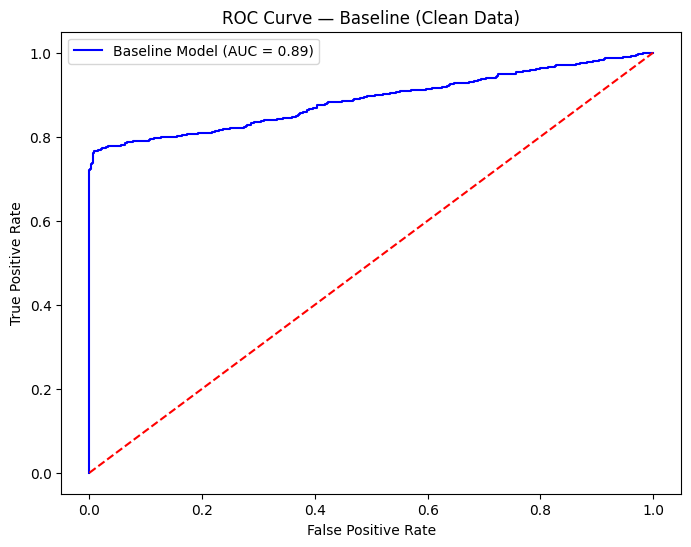

Baseline AUC: 0.8874


In [11]:
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred = torch.nn.functional.softmax(outputs, dim=1)[:, 1]

fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_pred.cpu().numpy())
auc_baseline = auc(fpr_baseline, tpr_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_baseline, tpr_baseline, color='blue', label=f'Baseline Model (AUC = {auc_baseline:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline (Clean Data)')
plt.legend()
plt.show()
print(f'Baseline AUC: {auc_baseline:.4f}')

## Define the PGD Attack

**Projected Gradient Descent (PGD)** is a multi-step adversarial attack introduced by Madry et al. (2018). It is considered the strongest first-order attack and is used to find **worst-case adversarial examples** within a constrained perturbation budget.

### Algorithm:
1. **Initialize** with random perturbation within ε-ball: `x_adv = x + Uniform(-ε, ε)`
2. **Repeat for K iterations:**
   - Compute gradient of the loss with respect to `x_adv`
   - Apply step: `x_adv = x_adv + α * sign(∇loss)`
   - **Project** back into the ε-ball: `x_adv = clip(x_adv, x - ε, x + ε)`

### Key Parameters:
- **ε (epsilon):** Maximum perturbation magnitude (perturbation budget)
- **α (alpha):** Step size per iteration
- **K (num_steps):** Number of gradient steps
- **random_start:** Whether to initialize with random noise (standard PGD uses True)

PGD is a **white-box attack** — it requires full access to model gradients.

In [12]:
def pgd_attack(model, x, y, epsilon=0.3, alpha=0.01, num_steps=40, random_start=True):
    """
    Projected Gradient Descent (PGD) adversarial attack.

    Parameters:
    -----------
    model       : trained PyTorch model
    x           : input tensor (clean samples)
    y           : true labels tensor
    epsilon     : maximum perturbation budget (L-inf norm)
    alpha       : step size per iteration
    num_steps   : number of PGD iterations
    random_start: if True, initialize with random perturbation within epsilon-ball

    Returns:
    --------
    x_adv : adversarially perturbed input tensor
    """
    criterion = nn.CrossEntropyLoss()

    # Clone the input so we don't modify the original
    x_adv = x.detach().clone()

    # Step 1: Random initialization within the epsilon-ball
    if random_start:
        x_adv = x_adv + torch.empty_like(x_adv).uniform_(-epsilon, epsilon)

    # Step 2: Iterative PGD steps
    for _ in range(num_steps):
        x_adv.requires_grad_(True)
        output = model(x_adv)
        loss = criterion(output, y)

        model.zero_grad()
        loss.backward()

        # Gradient ascent step (maximize loss)
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()

            # Step 3: Project back into epsilon-ball (clip perturbation)
            perturbation = torch.clamp(x_adv - x, -epsilon, epsilon)
            x_adv = x + perturbation

    return x_adv.detach()

## Evaluate PGD Attack Across Epsilon Values

The PGD attack is evaluated across a range of epsilon values to understand how the perturbation budget affects attack effectiveness. For each epsilon value:
- **Accuracy on adversarial examples** measures how often the model still classifies correctly
- **Attack Success Rate** measures how often the PGD attack successfully changes the model's prediction
- **False Negative Rate** measures how often actual attacks are misclassified as benign

PGD uses `alpha = epsilon / 10` (a standard heuristic) and `40 iterations`.

In [13]:
epsilon_values = [0.1, 0.2, 0.3, 0.4, 0.5]
num_steps = 40
accuracies_pgd = []
attack_success_rates = []
false_negative_rates = []

model.eval()
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Get clean predictions as baseline for attack success rate
with torch.no_grad():
    outputs_clean = model(X_test_tensor)
    _, y_pred_clean = torch.max(outputs_clean, 1)

print(f'PGD Attack Evaluation (num_steps={num_steps}, random_start=True)')
print('-' * 70)

for epsilon in epsilon_values:
    alpha = epsilon / 10  # Standard heuristic: alpha = epsilon / num_steps * 2.5

    x_adv = pgd_attack(
        model, X_test_tensor, y_test_tensor,
        epsilon=epsilon, alpha=alpha, num_steps=num_steps, random_start=True
    )

    with torch.no_grad():
        outputs_adv = model(x_adv)
        _, y_pred_adv = torch.max(outputs_adv, 1)

    accuracy_adv = accuracy_score(y_test.values, y_pred_adv.numpy())
    accuracies_pgd.append(accuracy_adv)

    attack_success_rate = np.mean(
        (y_pred_clean.numpy() != y_pred_adv.numpy()).astype(int)
    )
    attack_success_rates.append(attack_success_rate)

    false_negative_rate = np.mean(
        ((y_test.values == 1) & (y_pred_adv.numpy() == 0)).astype(int)
    )
    false_negative_rates.append(false_negative_rate)

    print(f'ε={epsilon:.1f} | Accuracy: {accuracy_adv:.4f} | '
          f'Attack Success Rate: {attack_success_rate:.4f} | '
          f'False Negative Rate: {false_negative_rate:.4f}')

PGD Attack Evaluation (num_steps=40, random_start=True)
----------------------------------------------------------------------
ε=0.1 | Accuracy: 0.6703 | Attack Success Rate: 0.2165 | False Negative Rate: 0.1965
ε=0.2 | Accuracy: 0.3192 | Attack Success Rate: 0.5676 | False Negative Rate: 0.3323
ε=0.3 | Accuracy: 0.1882 | Attack Success Rate: 0.6986 | False Negative Rate: 0.4009
ε=0.4 | Accuracy: 0.1132 | Attack Success Rate: 0.7736 | False Negative Rate: 0.4135
ε=0.5 | Accuracy: 0.0487 | Attack Success Rate: 0.8381 | False Negative Rate: 0.4188


### Results Interpretation

- **Accuracy on Adversarial Examples:** As epsilon increases, accuracy drops significantly — PGD finds more effective adversarial inputs at larger perturbation budgets.
- **Attack Success Rate:** Higher epsilon values allow PGD to flip more predictions, demonstrating the attack's power under larger perturbation allowances.
- **False Negative Rate:** Increases with epsilon, indicating the model increasingly fails to detect real intrusions when inputs are adversarially perturbed.

Compared to FGSM, PGD's iterative nature means it achieves higher attack success rates at the same epsilon values.

## Accuracy vs Epsilon (PGD Attack)

Plots the relationship between perturbation budget (ε) and model accuracy under PGD attack.

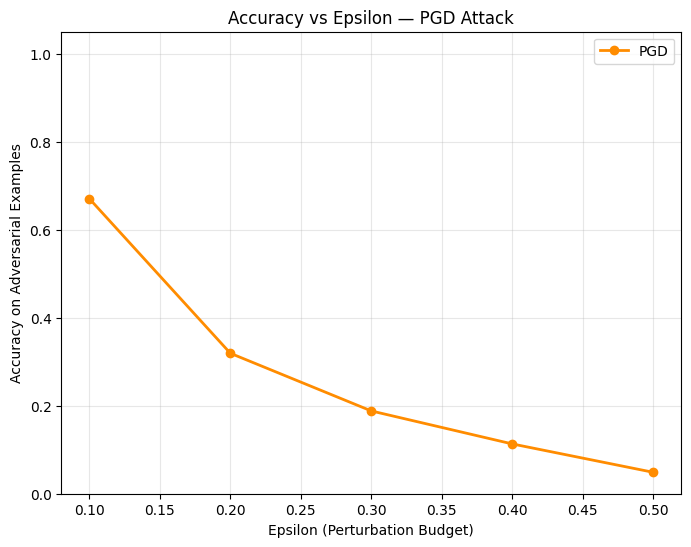

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies_pgd, marker='o', color='darkorange', linewidth=2, label='PGD')
plt.xlabel('Epsilon (Perturbation Budget)')
plt.ylabel('Accuracy on Adversarial Examples')
plt.title('Accuracy vs Epsilon — PGD Attack')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## Attack Success Rate vs Epsilon

From the attacker's perspective: how often does the PGD attack successfully cause misclassification?

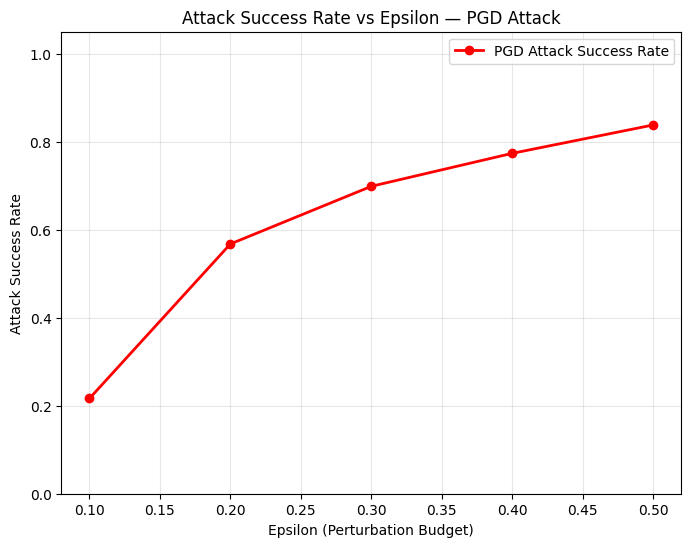

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, attack_success_rates, marker='o', linestyle='-',
         color='red', linewidth=2, label='PGD Attack Success Rate')
plt.xlabel('Epsilon (Perturbation Budget)')
plt.ylabel('Attack Success Rate')
plt.title('Attack Success Rate vs Epsilon — PGD Attack')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## Effect of Iteration Count on Attack Strength

A key differentiator of PGD from FGSM is its **iterative nature**. Here we evaluate how increasing the number of PGD steps affects attack effectiveness at a fixed epsilon. More iterations allow PGD to find stronger adversarial examples within the same perturbation budget.

Effect of Iteration Count on PGD Attack (ε=0.3)
------------------------------------------------------------
Steps=  1 | Alpha=0.3000 | Accuracy: 0.3595
Steps=  5 | Alpha=0.0600 | Accuracy: 0.3229
Steps= 10 | Alpha=0.0300 | Accuracy: 0.3265
Steps= 20 | Alpha=0.0150 | Accuracy: 0.3297
Steps= 40 | Alpha=0.0075 | Accuracy: 0.3187
Steps= 80 | Alpha=0.0037 | Accuracy: 0.3192


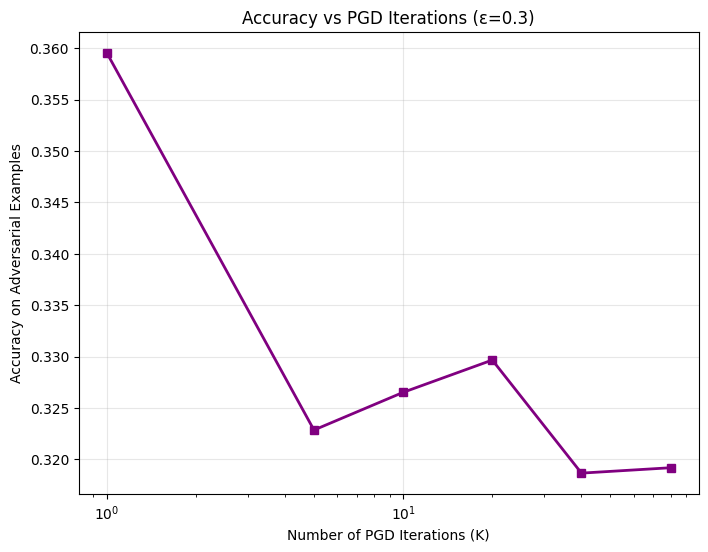

In [16]:
fixed_epsilon = 0.3
step_counts = [1, 5, 10, 20, 40, 80]
accuracies_by_steps = []

model.eval()

print(f'Effect of Iteration Count on PGD Attack (ε={fixed_epsilon})')
print('-' * 60)

for steps in step_counts:
    alpha = fixed_epsilon / max(steps, 1)

    x_adv = pgd_attack(
        model, X_test_tensor, y_test_tensor,
        epsilon=fixed_epsilon, alpha=alpha, num_steps=steps, random_start=True
    )

    with torch.no_grad():
        outputs_adv = model(x_adv)
        _, y_pred_adv = torch.max(outputs_adv, 1)

    accuracy_adv = accuracy_score(y_test.values, y_pred_adv.numpy())
    accuracies_by_steps.append(accuracy_adv)
    print(f'Steps={steps:3d} | Alpha={alpha:.4f} | Accuracy: {accuracy_adv:.4f}')

plt.figure(figsize=(8, 6))
plt.plot(step_counts, accuracies_by_steps, marker='s', color='purple', linewidth=2)
plt.xlabel('Number of PGD Iterations (K)')
plt.ylabel('Accuracy on Adversarial Examples')
plt.title(f'Accuracy vs PGD Iterations (ε={fixed_epsilon})')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

## ROC Curves Under PGD Attack

ROC curves are plotted for each epsilon value to show how the model's discriminative ability degrades under increasing PGD attack pressure. Lower AUC values indicate the model is performing closer to random chance.

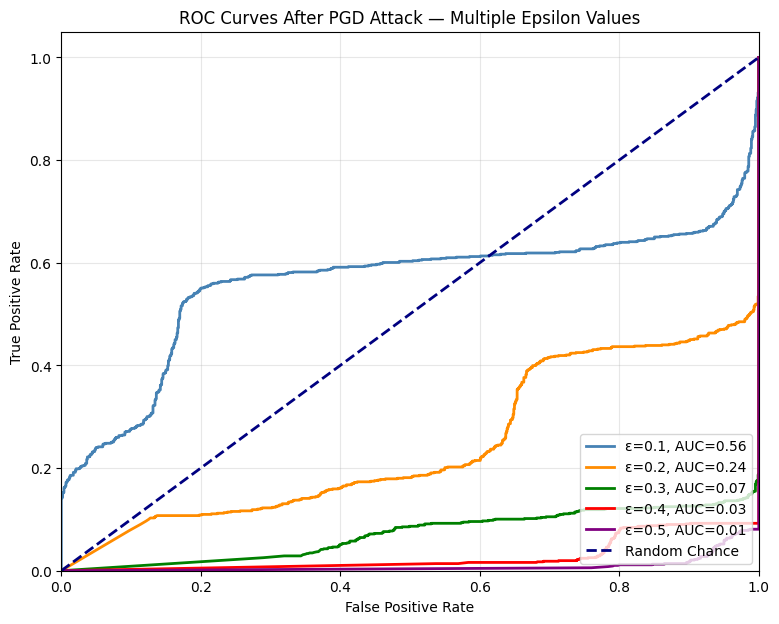

In [17]:
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, epsilon in enumerate(epsilon_values):
    alpha = epsilon / 10

    x_adv = pgd_attack(
        model, X_test_tensor, y_test_tensor,
        epsilon=epsilon, alpha=alpha, num_steps=40, random_start=True
    )

    with torch.no_grad():
        outputs_adv = model(x_adv)
        y_pred_proba_adv = torch.softmax(outputs_adv, dim=1)[:, 1].numpy()

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_adv)
    auc_value = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'ε={epsilon:.1f}, AUC={auc_value:.2f}')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves After PGD Attack — Multiple Epsilon Values')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

### Key Findings

**PGD as a Worst-Case Attacker:**
The Projected Gradient Descent attack demonstrates significantly stronger adversarial capabilities than single-step attacks like FGSM. By iteratively maximizing the loss while projecting perturbations back into the constrained ε-ball, PGD finds near-optimal adversarial examples within the perturbation budget.

**Epsilon Sensitivity:**
Model accuracy degrades rapidly as ε increases, confirming the model's vulnerability to bounded adversarial perturbations. Even small perturbation budgets (ε=0.1) result in meaningful accuracy drops compared to the clean baseline.

**Iteration Depth Matters:**
The iteration analysis shows that attack effectiveness increases with step count but converges — beyond a certain threshold of iterations, additional steps yield diminishing returns. This convergence behavior reflects PGD finding a local maximum of the adversarial loss within the ε-ball.

**Implications for IDS Security:**
An adversary with white-box access to the IDS model could craft inputs that reliably evade detection, with false negative rates exceeding 40% at larger epsilon values. This demonstrates the critical need for adversarial training and robust defenses in deployed IDS systems.

### Recommended Mitigations
- **Adversarial Training with PGD:** Train the model on PGD-generated examples (Madry et al. training) — the most effective known defense
- **Certified Defenses:** Use provably robust training methods that guarantee bounds on adversarial accuracy
- **Ensemble Methods:** Combine multiple models to increase the cost of successful attacks
- **Input Preprocessing:** Apply feature squeezing or randomized smoothing to disrupt adversarial perturbations